# Shipment Delivery Analysis
## Task: Analisis Data Pengiriman Anteraja

### 1. Setup & Load Data

In [18]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_squared_error

# Load dataset
df = pd.read_csv('shipments.csv')
print("Data loaded successfully!")
df.head()

Data loaded successfully!


,tracking_number,courier,weight_kg,distance_km,promised_hours,actual_hours,delay_hours
0,ANT0140,Sari,2.3,50.4,19,26.3,7.3
1,ANT0066,Andi,2.8,14.9,10,13.1,3.1
2,ANT0096,Budi,3.0,26.0,12,17.2,5.2
3,ANT0023,Dedi,3.1,13.6,9,10.3,1.3
4,ANT0064,Andi,2.0,11.5,9,10.8,1.8


### 2. Cleaning & Statistik

In [19]:
# Cek ukuran data
print(f"Shape: {df.shape}")
print(f"\nJumlah baris: {df.shape[0]}, Jumlah kolom: {df.shape[1]}")

Shape: (220, 7)

Jumlah baris: 220, Jumlah kolom: 7


In [20]:
# Cek tipe data
print("Info Data:")
df.info()

Info Data:
<class 'pandas.DataFrame'>
RangeIndex: 220 entries, 0 to 219
Data columns (total 7 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   tracking_number  220 non-null    str    
 1   courier          220 non-null    str    
 2   weight_kg        220 non-null    float64
 3   distance_km      220 non-null    float64
 4   promised_hours   220 non-null    int64  
 5   actual_hours     220 non-null    float64
 6   delay_hours      220 non-null    float64
dtypes: float64(4), int64(1), str(2)
memory usage: 12.2 KB


In [21]:
# Cek missing values dan duplikat
print(f"Missing values per kolom:")
print(df.isnull().sum())
print(f"\nJumlah data duplikat: {df.duplicated().sum()}")

Missing values per kolom:
tracking_number    0
courier            0
weight_kg          0
distance_km        0
promised_hours     0
actual_hours       0
delay_hours        0
dtype: int64

Jumlah data duplikat: 0


In [22]:
# Bersihkan data
# Pastikan kolom numerik bertipe float/int
numeric_cols = ['weight_kg', 'distance_km', 'promised_hours', 'actual_hours']
for col in numeric_cols:
    df[col] = pd.to_numeric(df[col], errors='coerce')

# Hapus baris kosong dan data duplikat
df_clean = df.dropna().drop_duplicates().copy()

# Validasi hasil cleaning
missing_after = df_clean.isnull().sum().sum()
duplicates_after = df_clean.duplicated().sum()

print(f"Data setelah cleaning: {df_clean.shape}")
print(f"Total missing values setelah cleaning: {missing_after}")
print(f"Jumlah duplikat setelah cleaning: {duplicates_after}")

assert missing_after == 0, "Masih ada nilai kosong setelah cleaning"
assert duplicates_after == 0, "Masih ada data duplikat setelah cleaning"

Data setelah cleaning: (220, 7)
Total missing values setelah cleaning: 0
Jumlah duplikat setelah cleaning: 0


In [23]:
# Hitung delay_hours (jika belum ada atau recalculate)
df_clean['delay_hours'] = df_clean['actual_hours'] - df_clean['promised_hours']

# Pastikan tidak ada nilai minus (batas bawah 0)
df_clean['delay_hours'] = df_clean['delay_hours'].clip(lower=0)

print("Kolom delay_hours berhasil dihitung.")
df_clean[['tracking_number', 'promised_hours', 'actual_hours', 'delay_hours']].head(10)

Kolom delay_hours berhasil dihitung.


,tracking_number,promised_hours,actual_hours,delay_hours
0,ANT0140,19,26.3,7.3
1,ANT0066,10,13.1,3.1
2,ANT0096,12,17.2,5.2
3,ANT0023,9,10.3,1.3
4,ANT0064,9,10.8,1.8
5,ANT0047,7,7.8,0.8
6,ANT0098,11,13.4,2.4
7,ANT0012,9,10.9,1.9
8,ANT0003,9,9.9,0.9
9,ANT0083,8,8.6,0.6


In [24]:
# Statistik delay_hours menggunakan NumPy
delay_values = df_clean['delay_hours'].values

min_delay = np.min(delay_values)
median_delay = np.median(delay_values)
mean_delay = np.mean(delay_values)
std_delay = np.std(delay_values)

print("=== Statistik Delay Hours ===")
print(f"Minimum: {min_delay:.2f} jam")
print(f"Median: {median_delay:.2f} jam")
print(f"Mean: {mean_delay:.2f} jam")
print(f"Standar Deviasi: {std_delay:.2f} jam")

=== Statistik Delay Hours ===
Minimum: 0.00 jam
Median: 3.05 jam
Mean: 4.14 jam
Standar Deviasi: 3.80 jam


### 3. Visualisasi, Grouping & Korelasi

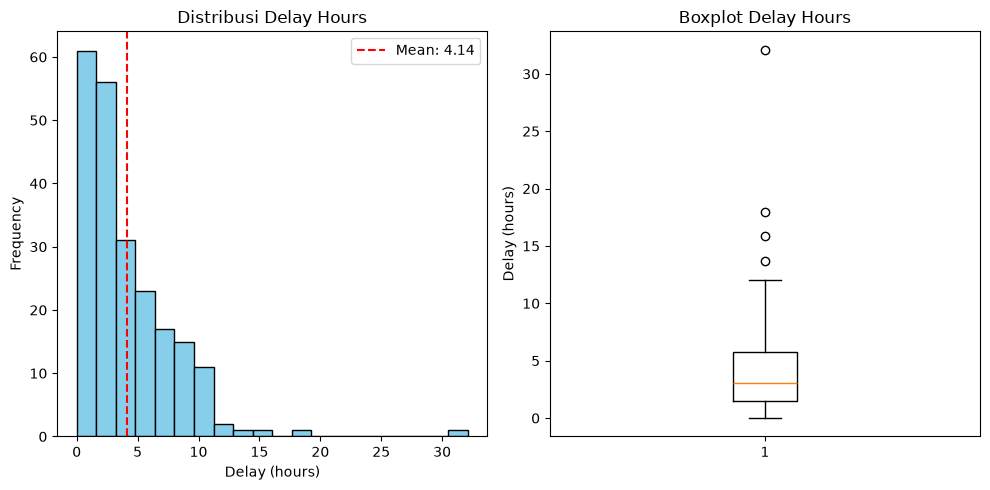

In [25]:
# Visualisasi distribusi delay_hours
plt.figure(figsize=(10, 5))

plt.subplot(1, 2, 1)
plt.hist(df_clean['delay_hours'], bins=20, color='skyblue', edgecolor='black')
plt.xlabel('Delay (hours)')
plt.ylabel('Frequency')
plt.title('Distribusi Delay Hours')
plt.axvline(mean_delay, color='red', linestyle='--', label=f'Mean: {mean_delay:.2f}')
plt.legend()

plt.subplot(1, 2, 2)
plt.boxplot(df_clean['delay_hours'])
plt.ylabel('Delay (hours)')
plt.title('Boxplot Delay Hours')

plt.tight_layout()
plt.show()

In [26]:
# Metode 1: grouping manual menggunakan loop dan dictionary
courier_delays = {}
for courier, delay in zip(df_clean['courier'], df_clean['delay_hours']):
    if courier not in courier_delays:
        courier_delays[courier] = []
    courier_delays[courier].append(delay)

manual_means = {}
for courier, delays in courier_delays.items():
    manual_means[courier] = np.mean(delays)

# Metode 2: grouping menggunakan Pandas groupby()
groupby_means = df_clean.groupby('courier')['delay_hours'].mean()
delay_by_courier = df_clean.groupby('courier')['delay_hours'].agg(['mean', 'median', 'std', 'count'])
delay_by_courier = delay_by_courier.sort_values('mean', ascending=False)

comparison = pd.DataFrame({
    'loop_manual': pd.Series(manual_means),
    'groupby': groupby_means
}).sort_values('groupby', ascending=False)
comparison['selisih'] = comparison['loop_manual'] - comparison['groupby']

print("=== Perbandingan Loop Manual vs groupby() ===")
print(comparison.round(4))
assert np.allclose(comparison['loop_manual'], comparison['groupby'])

print("\n=== Detail Delay Hours per Courier ===")
print(delay_by_courier.round(2))

=== Perbandingan Loop Manual vs groupby() ===
       loop_manual  groupby  selisih
Citra       7.9023   7.9023     -0.0
Sari        5.8000   5.8000      0.0
Budi        3.4000   3.4000      0.0
Andi        2.1000   2.1000      0.0
Dedi        1.6024   1.6024      0.0

=== Detail Delay Hours per Courier ===
         mean  median   std  count
courier                           
Citra     7.9    7.50  2.83     43
Sari      5.8    5.75  2.19     44
Budi      3.4    2.90  4.57     45
Andi      2.1    1.75  2.25     46
Dedi      1.6    1.15  2.56     42


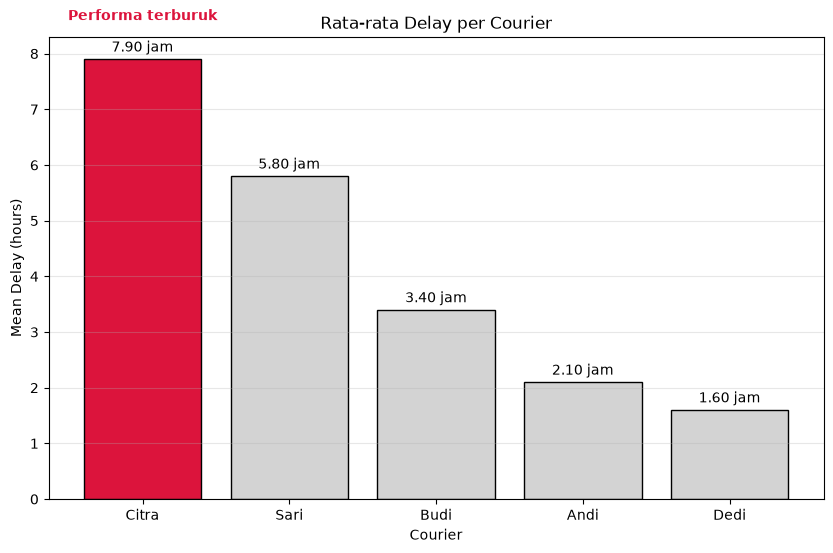

In [27]:
# Visualisasi delay per courier dan sorot courier dengan performa terburuk
worst_courier = delay_by_courier.index[0]
bar_colors = ['crimson' if courier == worst_courier else 'lightgray'
              for courier in delay_by_courier.index]

plt.figure(figsize=(10, 6))
bars = plt.bar(delay_by_courier.index, delay_by_courier['mean'],
               color=bar_colors, edgecolor='black')
plt.xlabel('Courier')
plt.ylabel('Mean Delay (hours)')
plt.title('Rata-rata Delay per Courier')
plt.grid(axis='y', alpha=0.3)
plt.bar_label(bars, fmt='%.2f jam', padding=3)
plt.text(0, delay_by_courier.iloc[0]['mean'] + 0.7, 'Performa terburuk',
         ha='center', color='crimson', fontweight='bold')
plt.show()

In [28]:
# Korelasi antar variabel numerik
correlation_matrix = df_clean[['weight_kg', 'distance_km', 'promised_hours', 'actual_hours', 'delay_hours']].corr()

print("=== Correlation Matrix ===")
print(correlation_matrix.round(3))

=== Correlation Matrix ===
                weight_kg  distance_km  promised_hours  actual_hours  \
weight_kg           1.000        0.203           0.197         0.225   
distance_km         0.203        1.000           0.998         0.929   
promised_hours      0.197        0.998           1.000         0.928   
actual_hours        0.225        0.929           0.928         1.000   
delay_hours         0.220        0.710           0.706         0.919   

                delay_hours  
weight_kg             0.220  
distance_km           0.710  
promised_hours        0.706  
actual_hours          0.919  
delay_hours           1.000  


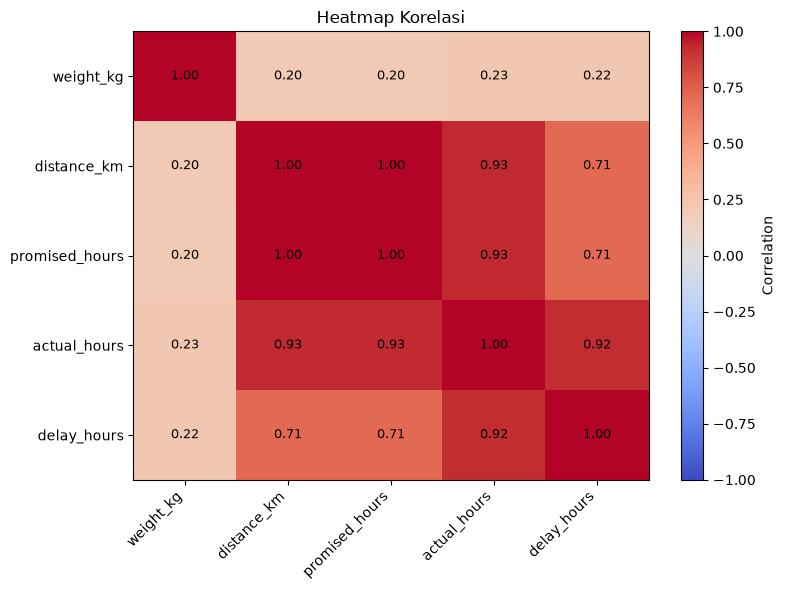

In [29]:
# Visualisasi korelasi dengan heatmap
plt.figure(figsize=(8, 6))
plt.imshow(correlation_matrix, cmap='coolwarm', aspect='auto', vmin=-1, vmax=1)
plt.colorbar(label='Correlation')
plt.xticks(range(len(correlation_matrix.columns)), correlation_matrix.columns, rotation=45, ha='right')
plt.yticks(range(len(correlation_matrix.columns)), correlation_matrix.columns)
plt.title('Heatmap Korelasi')

# Tambahkan nilai korelasi di setiap cell
for i in range(len(correlation_matrix)):
    for j in range(len(correlation_matrix)):
        plt.text(j, i, f'{correlation_matrix.iloc[i, j]:.2f}', 
                ha='center', va='center', color='black', fontsize=9)

plt.tight_layout()
plt.show()

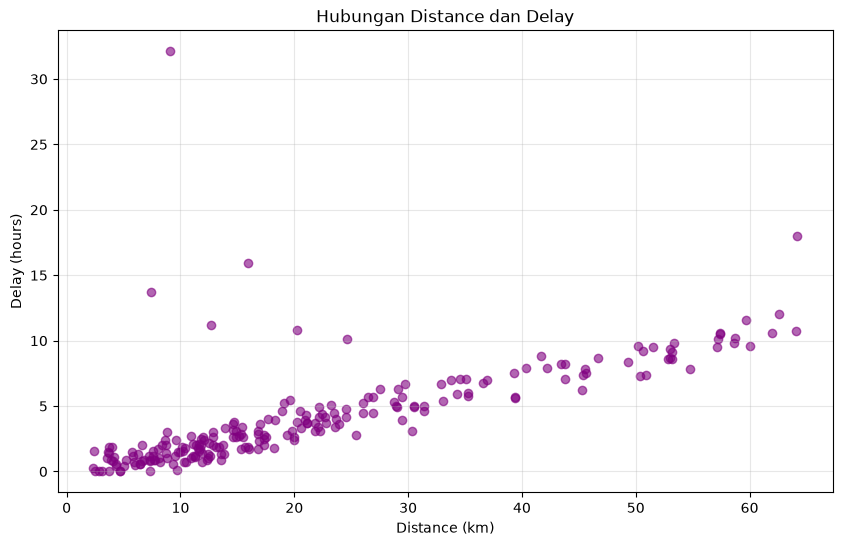

In [30]:
# Scatter plot: distance_km vs delay_hours
plt.figure(figsize=(10, 6))
plt.scatter(df_clean['distance_km'], df_clean['delay_hours'], alpha=0.6, color='purple')
plt.xlabel('Distance (km)')
plt.ylabel('Delay (hours)')
plt.title('Hubungan Distance dan Delay')
plt.grid(alpha=0.3)
plt.show()

### 4. Linear Regression Model

In [31]:
# Prediksi delay_hours berdasarkan distance_km dan weight_kg
X = df_clean[['distance_km', 'weight_kg']]
y = df_clean['delay_hours']

# Bagi data menjadi 80% data latih dan 20% data uji
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Latih model hanya menggunakan data latih
model = LinearRegression()
model.fit(X_train, y_train)

# Evaluasi menggunakan data uji yang tidak digunakan saat training
y_pred = model.predict(X_test)
r2 = r2_score(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

print("=== Linear Regression Results (Test Set) ===")
print(f"Data latih: {len(X_train)} baris | Data uji: {len(X_test)} baris")
print("Coefficients:")
print(f"  - Distance (km): {model.coef_[0]:.4f}")
print(f"  - Weight (kg): {model.coef_[1]:.4f}")
print(f"  - Intercept: {model.intercept_:.4f}")
print(f"\nR² Test Score: {r2:.4f}")
print(f"Test RMSE: {rmse:.4f} jam")

=== Linear Regression Results (Test Set) ===
Data latih: 176 baris | Data uji: 44 baris
Coefficients:
  - Distance (km): 0.1664
  - Weight (kg): 0.2357
  - Intercept: -0.3241

R² Test Score: 0.5248
Test RMSE: 2.4488 jam


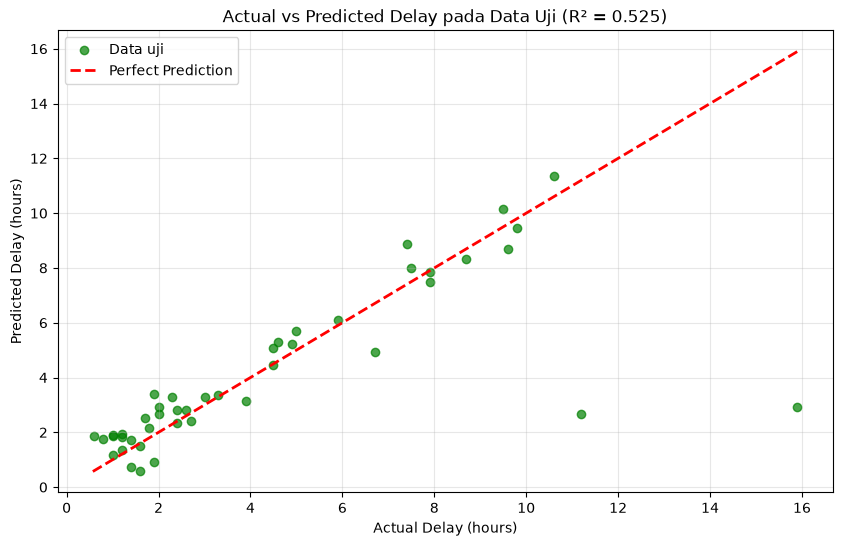

In [32]:
# Visualisasi prediksi vs nilai aktual pada data uji
plt.figure(figsize=(10, 6))
plt.scatter(y_test, y_pred, alpha=0.7, color='green', label='Data uji')
plot_min = min(y_test.min(), y_pred.min())
plot_max = max(y_test.max(), y_pred.max())
plt.plot([plot_min, plot_max], [plot_min, plot_max], 'r--', lw=2, label='Perfect Prediction')
plt.xlabel('Actual Delay (hours)')
plt.ylabel('Predicted Delay (hours)')
plt.title(f'Actual vs Predicted Delay pada Data Uji (R² = {r2:.3f})')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

### 5. Kesimpulan Bisnis

In [33]:
# Bandingkan rate keterlambatan pengiriman jarak jauh dan dekat
far_shipments = df_clean[df_clean['distance_km'] > 50]
near_shipments = df_clean[df_clean['distance_km'] < 10]
delay_threshold = 2

distance_comparison = pd.DataFrame({
    'Jarak jauh (>50 km)': {
        'Jumlah pengiriman': len(far_shipments),
        'Rate delay >0 jam (%)': (far_shipments['delay_hours'] > 0).mean() * 100,
        'Rate delay >2 jam (%)': (far_shipments['delay_hours'] > delay_threshold).mean() * 100
    },
    'Jarak dekat (<10 km)': {
        'Jumlah pengiriman': len(near_shipments),
        'Rate delay >0 jam (%)': (near_shipments['delay_hours'] > 0).mean() * 100,
        'Rate delay >2 jam (%)': (near_shipments['delay_hours'] > delay_threshold).mean() * 100
    }
}).T

far_rate = distance_comparison.loc['Jarak jauh (>50 km)', 'Rate delay >2 jam (%)']
near_rate = distance_comparison.loc['Jarak dekat (<10 km)', 'Rate delay >2 jam (%)']
rate_ratio = far_rate / near_rate if near_rate > 0 else np.inf

print("=== Perbandingan Keterlambatan Berdasarkan Jarak ===")
print(distance_comparison.round(2))

# Analisis final
print("=== Insight & Kesimpulan ===")
print(f"1. Rata-rata delay: {mean_delay:.2f} jam dengan standar deviasi {std_delay:.2f} jam")
print(f"2. Courier dengan delay tertinggi: {delay_by_courier.index[0]} ({delay_by_courier.iloc[0]['mean']:.2f} jam)")
print(f"3. Courier dengan delay terendah: {delay_by_courier.index[-1]} ({delay_by_courier.iloc[-1]['mean']:.2f} jam)")
print(f"4. Korelasi distance vs delay: {correlation_matrix.loc['distance_km', 'delay_hours']:.3f}")
print(f"5. Model regression R² pada data uji: {r2:.3f} - {'baik' if r2 > 0.7 else 'cukup' if r2 > 0.5 else 'lemah'}")

print("\n=== KESIMPULAN BISNIS ===")
business_insight = (
    f"Pengiriman di atas 50 km mengalami keterlambatan lebih dari {delay_threshold} jam sebesar "
    f"{far_rate:.1f}%, sekitar {rate_ratio:.1f}× lebih sering dibandingkan pengiriman di bawah "
    f"10 km yang hanya {near_rate:.1f}%, sehingga kapasitas dan perencanaan rute jarak jauh "
    f"perlu diprioritaskan."
)
print(business_insight)

=== Perbandingan Keterlambatan Berdasarkan Jarak ===
                      Jumlah pengiriman  Rate delay >0 jam (%)  \
Jarak jauh (>50 km)                24.0                 100.00   
Jarak dekat (<10 km)               54.0                  87.04   

                      Rate delay >2 jam (%)  
Jarak jauh (>50 km)                  100.00  
Jarak dekat (<10 km)                   9.26  
=== Insight & Kesimpulan ===
1. Rata-rata delay: 4.14 jam dengan standar deviasi 3.80 jam
2. Courier dengan delay tertinggi: Citra (7.90 jam)
3. Courier dengan delay terendah: Dedi (1.60 jam)
4. Korelasi distance vs delay: 0.710
5. Model regression R² pada data uji: 0.525 - cukup

=== KESIMPULAN BISNIS ===
Pengiriman di atas 50 km mengalami keterlambatan lebih dari 2 jam sebesar 100.0%, sekitar 10.8× lebih sering dibandingkan pengiriman di bawah 10 km yang hanya 9.3%, sehingga kapasitas dan perencanaan rute jarak jauh perlu diprioritaskan.
